# Task 2: Analysis of Top 5 Model Trajectories

This notebook analyses the message count metrics computed by the trajectory analysis tool across all 500 trajectories for each of the five top ranked models on the mini SWE agent v2 leaderboard (Bash Only, SWE bench Verified). The models compared are Claude 4.5 Opus (high reasoning), Claude Opus 4.6, Gemini 3 Flash (high reasoning), MiniMax M2.5 (high reasoning), and GPT 5.2 Codex.

The analysis is present as a markdown content along with the results. 

In [16]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# All result files are in the same folder
CSV_FOLDER = Path("tracked_data")

df1 = pd.read_csv(CSV_FOLDER / "claude-4-5-opus-high_counts.csv")
df2 = pd.read_csv(CSV_FOLDER / "claude-opus-4-6_counts.csv")
df3 = pd.read_csv(CSV_FOLDER / "gemini-3-flash-high_counts.csv")
df4 = pd.read_csv(CSV_FOLDER / "minimax-m2-5-high_counts.csv")
df5 = pd.read_csv(CSV_FOLDER / "gpt5-2-codex_counts.csv")

In [3]:
# Drop the TOTAL row from each
for df in [df1, df2, df3, df4, df5]:
    df.drop(df[df["file"] == "TOTAL"].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

In [4]:
# Combining all models result data with a new row with model name in it.
df1["model"] = "claude-4-5-opus-high"
df2["model"] = "claude-opus-4-6"
df3["model"] = "gemini-3-flash-high"
df4["model"] = "minimax-m2-5-high"
df5["model"] = "gpt5-2-codex"

all_df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
print(f"Total rows: {len(all_df)}")
all_df.head()

Total rows: 2500


,file,system,user,assistant,tool,unknown,total,model
0,01d64b7b-9e56-4106-b0f0-9c0df7d011f8.json,1,1,21,28,0,51,claude-4-5-opus-high
1,02e8349d-6e72-4c6d-8dc9-fda68484b5cb.json,1,1,40,50,0,92,claude-4-5-opus-high
2,04c1fc64-17c0-4903-854d-af51762337ac.json,1,1,32,35,0,69,claude-4-5-opus-high
3,0577f4cd-ec66-4a77-a9b5-2e09c79af83b.json,1,1,51,61,0,114,claude-4-5-opus-high
4,06304cc4-ea4d-4680-bef2-a78af28c0972.json,1,1,35,47,0,84,claude-4-5-opus-high


In [5]:
# Check if unknown is always 0
print(all_df["unknown"].unique())
print(all_df["unknown"].sum())

[0]
0


For all models no unknown roles that did not belong to the categories "system", "user", "assistant", and "tool" were observed.  

In [6]:
all_df.drop(columns=["unknown"], inplace=True)

In [7]:
all_df.head()

,file,system,user,assistant,tool,total,model
0,01d64b7b-9e56-4106-b0f0-9c0df7d011f8.json,1,1,21,28,51,claude-4-5-opus-high
1,02e8349d-6e72-4c6d-8dc9-fda68484b5cb.json,1,1,40,50,92,claude-4-5-opus-high
2,04c1fc64-17c0-4903-854d-af51762337ac.json,1,1,32,35,69,claude-4-5-opus-high
3,0577f4cd-ec66-4a77-a9b5-2e09c79af83b.json,1,1,51,61,114,claude-4-5-opus-high
4,06304cc4-ea4d-4680-bef2-a78af28c0972.json,1,1,35,47,84,claude-4-5-opus-high


In [8]:
all_df.groupby("model")["total"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-4-5-opus-high,500.0,72.41,34.40,14.0,48.0,63.0,86.0,222.0
claude-opus-4-6,500.0,60.84,40.15,11.0,33.0,49.0,75.0,288.0
gemini-3-flash-high,500.0,113.24,38.88,2.0,87.0,109.0,131.5,319.0
gpt5-2-codex,500.0,72.88,34.51,17.0,47.0,65.0,89.0,251.0
minimax-m2-5-high,500.0,121.89,73.18,23.0,73.0,105.0,151.0,502.0


In [9]:
all_df.groupby("model")["system"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-4-5-opus-high,500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
claude-opus-4-6,500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
gemini-3-flash-high,500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
gpt5-2-codex,500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
minimax-m2-5-high,500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


For each model, we observe only 1 system message for all tasks.

In [10]:
all_df.groupby("model")["user"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-4-5-opus-high,500.0,1.00,0.09,1.0,1.0,1.0,1.0,3.0
claude-opus-4-6,500.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
gemini-3-flash-high,500.0,1.01,0.15,1.0,1.0,1.0,1.0,4.0
gpt5-2-codex,500.0,1.01,0.08,1.0,1.0,1.0,1.0,2.0
minimax-m2-5-high,500.0,1.01,0.11,1.0,1.0,1.0,1.0,2.0


For all the models, we observe a mean and median of 1.0 indicating that majority of the trajectories contain only 1 user message. However, all models except claude-opus-4-6 show a max user role messages more than 1.0 

In [11]:
all_df.groupby("model")["assistant"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-4-5-opus-high,500.0,32.89,15.53,6.0,22.0,29.0,40.00,109.0
claude-opus-4-6,500.0,28.93,19.46,5.0,16.0,23.0,36.00,140.0
gemini-3-flash-high,500.0,56.11,19.45,0.0,43.0,54.0,65.25,159.0
gpt5-2-codex,500.0,35.04,17.24,8.0,22.0,31.0,44.00,125.0
minimax-m2-5-high,500.0,60.44,36.57,11.0,36.0,52.0,75.00,250.0


In [12]:
all_df.groupby("model")["tool"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
claude-4-5-opus-high,500.0,37.51,19.15,6.0,24.0,32.5,46.00,121.0
claude-opus-4-6,500.0,29.91,20.76,4.0,16.0,24.0,37.25,146.0
gemini-3-flash-high,500.0,55.12,19.43,0.0,42.0,53.0,64.25,158.0
gpt5-2-codex,500.0,35.84,17.52,7.0,23.0,32.0,44.00,124.0
minimax-m2-5-high,500.0,59.44,36.61,10.0,35.0,51.0,74.00,250.0


In [13]:
# Combined stats table
all_df.groupby("model")[["assistant", "tool", "total"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

assistant                          tool                \
                          mean median    std min  max   mean median    std   
model                                                                        
claude-4-5-opus-high     32.89   29.0  15.53   6  109  37.51   32.5  19.15   
claude-opus-4-6          28.93   23.0  19.46   5  140  29.91   24.0  20.76   
gemini-3-flash-high      56.11   54.0  19.45   0  159  55.12   53.0  19.43   
gpt5-2-codex             35.04   31.0  17.24   8  125  35.84   32.0  17.52   
minimax-m2-5-high        60.44   52.0  36.57  11  250  59.44   51.0  36.61   

                                total                         
                     min  max    mean median    std min  max  
model                                                         
claude-4-5-opus-high   6  121   72.41   63.0  34.40  14  222  
claude-opus-4-6        4  146   60.84   49.0  40.15  11  288  
gemini-3-flash-high    0  158  113.24  109.0  38.88   2  319  
gpt5-2-codex           7  124   72.88   65.0  34.51  17  251  
minimax-m2-5-high     10  250  121.89  105.0  73.18  23  502

The combined statistics across assistant, tool and total messages confirm a clear split between the models. Claude Opus 4.6 and Claude 4.5 Opus High are the most concise, with lower means and medians across all three columns(assistant, tool, and total). MiniMax M2.5 stands out with the highest standard deviation in both assistant and tool counts, indicating highly inconsistent behaviour across tasks. Gemini 3 Flash shows a tighter spread despite a high mean, suggesting it is verbose but at least predictable. GPT 5.2 Codex sits close to the Claude models in all three metrics.

In [14]:
# Ratio of Assistant vs Tool roles
ratio = all_df.groupby("model")[["assistant", "tool"]].sum()
ratio["ratio_A/T"] = (ratio["assistant"] / ratio["tool"]).round(3)
ratio

,assistant,tool,ratio_A/T
model,,,
claude-4-5-opus-high,16446,18757,0.877
claude-opus-4-6,14466,14956,0.967
gemini-3-flash-high,28054,27559,1.018
gpt5-2-codex,17520,17918,0.978
minimax-m2-5-high,30219,29722,1.017


In a standard ReAct agent loop, each assistant message should trigger exactly one tool call, giving a ratio close to 1.0. Gemini 3 Flash, MiniMax M2.5, GPT 5.2 Codex, and Claude Opus 4.6 are closest to this ideal. Claude 4.5 Opus High is the notable outlier with a ratio of 0.877, meaning it receives more tool responses than it makes assistant turns. This suggests the scaffold occasionally injects tool results without a preceding assistant message, or that some assistant messages trigger multiple tool calls within a single turn.

In [20]:
# Percentage of models finishing within 50 and 100 messages
for model, grp in all_df.groupby("model"):
    p50  = (grp["total"] <= 50).mean() * 100
    p100 = (grp["total"] <= 100).mean() * 100
    print(f"{model}: {p50:.1f}% within 50 msgs | {p100:.1f}% within 100 msgs")

claude-4-5-opus-high: 29.8% within 50 msgs | 83.4% within 100 msgs
claude-opus-4-6: 52.4% within 50 msgs | 86.2% within 100 msgs
gemini-3-flash-high: 1.8% within 50 msgs | 39.0% within 100 msgs
gpt5-2-codex: 28.6% within 50 msgs | 81.4% within 100 msgs
minimax-m2-5-high: 6.2% within 50 msgs | 46.8% within 100 msgs


Form the above data we observe,
Claude Opus 4.6 completes the largest share of tasks within short trajectory budgets. Over half of its trajectories finish within 50 messages, and the vast majority wrap up within 100. Gemini 3 Flash High is at the opposite end, with very few trajectories finishing within 50 messages and a substantial portion exceeding 100. These numbers are directly useful for estimating compute costs in practice as shorter trajectories mean fewer API calls and lower inference cost per task.

/var/folders/8s/zgkxwqdx21jd_2p4vdhph9140000gn/T/ipykernel_52750/1245332838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_df, x="model", y="total", palette="muted", ax=ax)


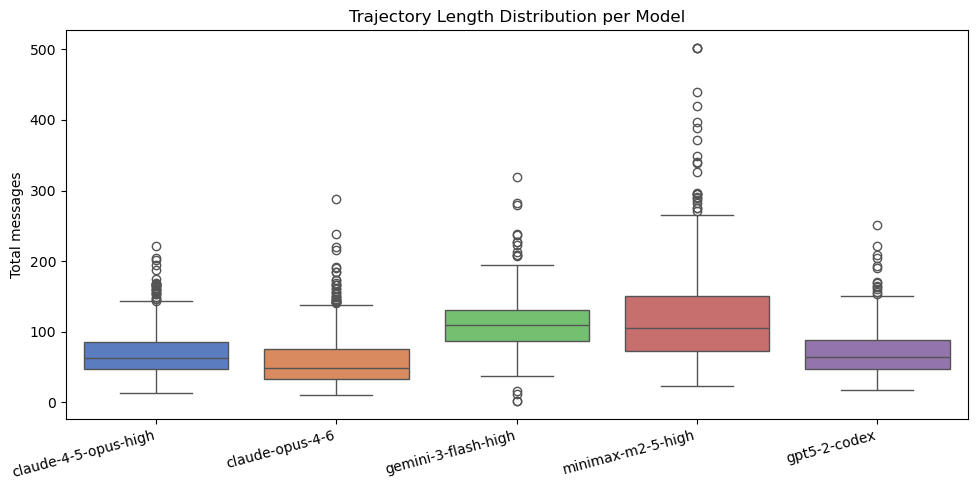

In [17]:
# Box plot to observe the length distribution of each model
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=all_df, x="model", y="total", palette="muted", ax=ax)
ax.set_title("Trajectory Length Distribution per Model")
ax.set_xlabel("")
ax.set_ylabel("Total messages")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

The box plot makes the spread differences immediately visible. We observe many high outliner for all the models. Claude Opus 4.6 and Claude 4.5 Opus High have compact boxes sitting low on the y axis, with relatively few high outliers. MiniMax M2.5 High has the widest box and the highest outliers, with some trajectories reaching over 500 messages. Gemini 3 Flash High has a narrower spread than MiniMax despite a similar mean, which reflects the lower standard deviation we saw in the stats table. The outliers across all models likely correspond to tasks where the agent hit its step limit without resolving the issue.

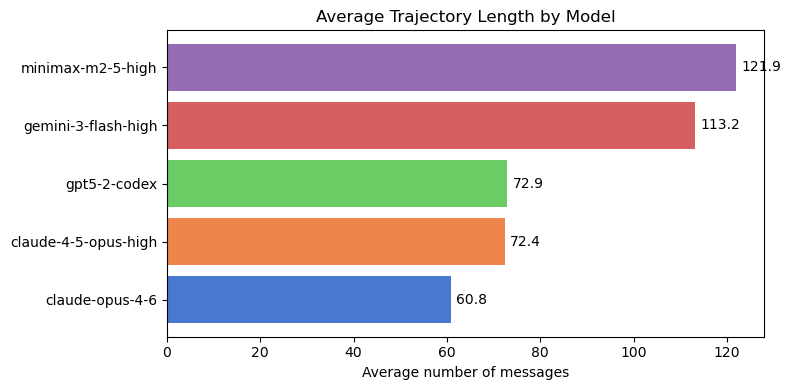

In [19]:
# Bar chart of average tragejectory for each model
avg = all_df.groupby("model")["total"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(avg.index, avg.values, color=sns.color_palette("muted", len(avg)))
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_xlabel("Average number of messages")
ax.set_title("Average Trajectory Length by Model")
plt.tight_layout()
plt.show()

The bar chart gives a clean summary of the efficiency ranking. Claude Opus 4.6 is the most concise model at 60.8 messages on average, followed closely by Claude 4.5 Opus High and GPT 5.2 Codex which are nearly identical at around 72 messages. Gemini 3 Flash High and MiniMax M2.5 High require roughly twice as many messages to attempt the same tasks. It is worth noting that trajectory length alone does not measure success rate, a model could be concise because it gives up early rather than because it solves tasks efficiently.